In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/loan_applications.csv')
df['has_documentation'] = df['documented_monthly_income'].notna().astype(int)

## 1. Feature Engineering

In [3]:
df['income_ratio'] = np.where(
    df['has_documentation'] == 1,
    df['stated_monthly_income'] / df['documented_monthly_income'].replace(0, np.nan),
    np.nan
)

df['loan_to_income'] = df['loan_amount'] / df['stated_monthly_income'].replace(0, np.nan)
df['withdrawal_ratio'] = df['monthly_withdrawals'] / df['monthly_deposits'].replace(0, np.nan)
df['income_doc_filled'] = df['documented_monthly_income'].fillna(df['stated_monthly_income'])
df['income_ratio_filled'] = df['income_ratio'].fillna(1.0)

le = LabelEncoder()
df['employment_encoded'] = le.fit_transform(df['employment_status'])

FEATURES = [
    'stated_monthly_income',
    'income_doc_filled',
    'income_ratio_filled',
    'has_documentation',
    'loan_amount',
    'loan_to_income',
    'bank_ending_balance',
    'bank_has_overdrafts',
    'bank_has_consistent_deposits',
    'monthly_withdrawals',
    'monthly_deposits',
    'withdrawal_ratio',
    'num_documents_submitted',
    'employment_encoded',
]

FEATURE_LABELS = [
    'Stated Income',
    'Documented Income',
    'Income Ratio',
    'Has Documentation',
    'Loan Amount',
    'Loan-to-Income',
    'Bank Balance',
    'Has Overdrafts',
    'Consistent Deposits',
    'Monthly Withdrawals',
    'Monthly Deposits',
    'Withdrawal Ratio',
    'Num Documents',
    'Employment Status',
]

print(f'Features: {len(FEATURES)}')
print(df[FEATURES].isnull().sum()[df[FEATURES].isnull().sum() > 0])

Features: 14
Series([], dtype: int64)


## 2. Train / Test Split

In [4]:
known = df[df.actual_outcome != 'ongoing'].copy()
known['defaulted'] = (known.actual_outcome == 'defaulted').astype(int)

X = known[FEATURES]
y = known['defaulted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)}  Test: {len(X_test)}')
print(f'Train default rate: {y_train.mean():.1%}')
print(f'Test default rate:  {y_test.mean():.1%}')

Train: 1468  Test: 368
Train default rate: 29.7%
Test default rate:  29.6%


## 3. Model Training

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    base_score=0.5,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)

cv_scores = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(5), scoring='roc_auc')
print(f'CV AUC-ROC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

CV AUC-ROC: 0.683 ± 0.003


## 4. Threshold Selection

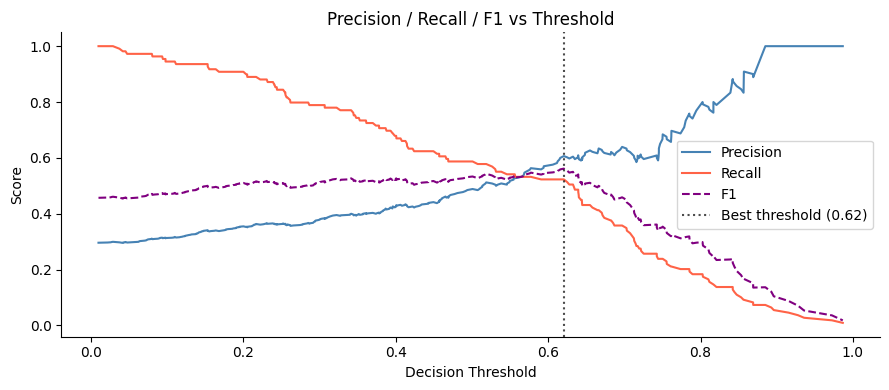

Best threshold (max F1): 0.621


In [6]:
y_prob = model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='tomato')
ax.plot(thresholds, f1_scores[:-1], label='F1', color='purple', linestyle='--')
ax.axvline(best_thresh, color='black', linestyle=':', alpha=0.7, label=f'Best threshold ({best_thresh:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best threshold (max F1): {best_thresh:.3f}')
y_pred = (y_prob >= best_thresh).astype(int)

## 5. Model Evaluation

In [7]:
def get_metrics(y_true, y_pred, y_prob, label='Model'):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'label': label,
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_prob),
        'fpr': fp / (fp + tn),
        'fnr': fn / (fn + tp),
        'cm': cm
    }

rule_map = {'approved': 0, 'flagged_for_review': 0, 'denied': 1}
rule_pred = known.loc[X_test.index, 'rule_based_decision'].map(rule_map).values
rule_score_norm = known.loc[X_test.index, 'rule_based_score'].values / 100
rule_prob = 1 - rule_score_norm

ml_metrics   = get_metrics(y_test, y_pred, y_prob, 'XGBoost')
rule_metrics = get_metrics(y_test, rule_pred, rule_prob, 'Rule-Based')

summary = pd.DataFrame([ml_metrics, rule_metrics]).set_index('label').drop(columns='cm')
print(summary.round(3))

            precision  recall     f1  auc_roc    fpr    fnr
label                                                      
XGBoost         0.606   0.523  0.562    0.715  0.143  0.477
Rule-Based      0.621   0.330  0.431    0.722  0.085  0.670


## 6. Confusion Matrices

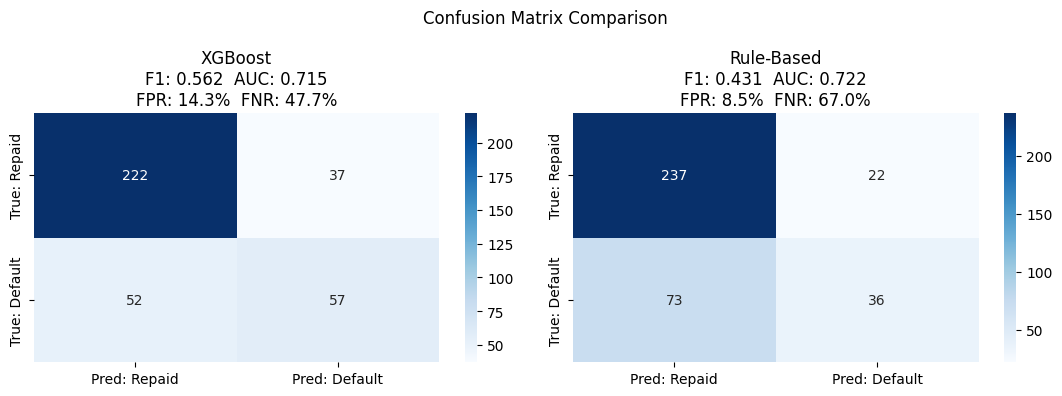

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metrics in zip(axes, [ml_metrics, rule_metrics]):
    cm = metrics['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Repaid', 'Pred: Default'],
                yticklabels=['True: Repaid', 'True: Default'])
    ax.set_title(
        f"{metrics['label']}\n"
        f"F1: {metrics['f1']:.3f}  AUC: {metrics['auc_roc']:.3f}\n"
        f"FPR: {metrics['fpr']:.1%}  FNR: {metrics['fnr']:.1%}"
    )

plt.suptitle('Confusion Matrix Comparison', fontsize=12)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. ROC Curves

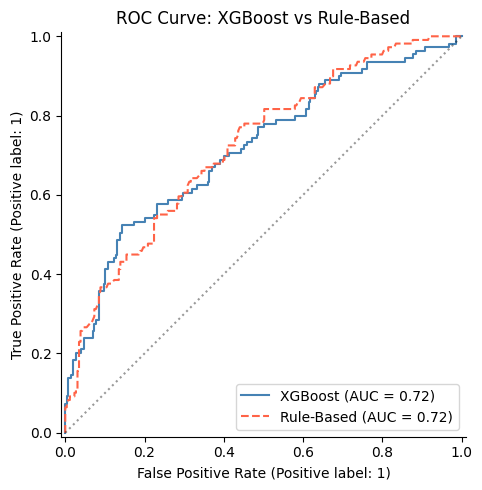

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, name='XGBoost', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test, rule_prob, name='Rule-Based', ax=ax, color='tomato', linestyle='--')
ax.plot([0,1],[0,1], 'k:', alpha=0.4)
ax.set_title('ROC Curve: XGBoost vs Rule-Based')
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

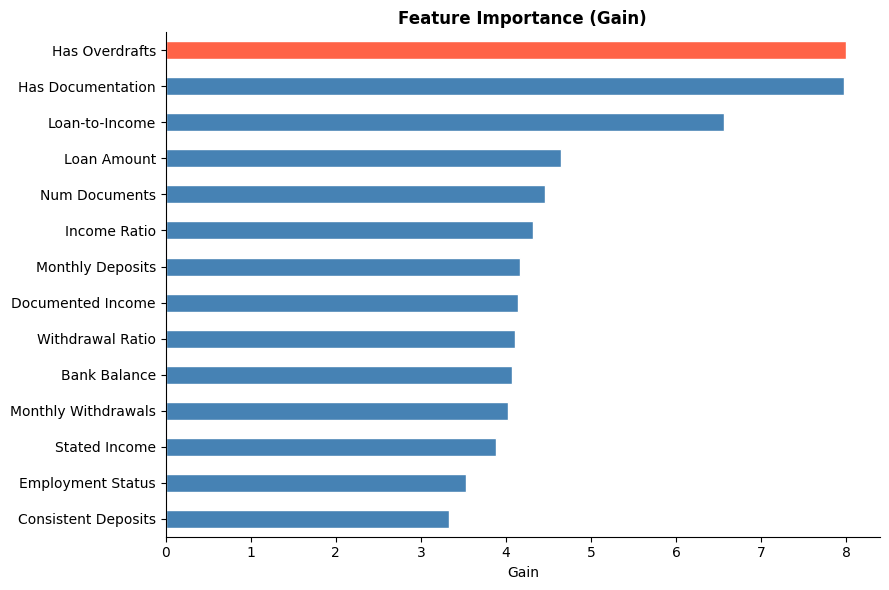

Top 5 features by gain:
Has Overdrafts       7.997457
Has Documentation    7.975795
Loan-to-Income       6.567013
Loan Amount          4.645926
Num Documents        4.455685
dtype: float64


In [10]:
booster = model.get_booster()
raw_importance = booster.get_score(importance_type='gain')

importance = pd.Series(
    {FEATURE_LABELS[int(k[1:]) if k.startswith('f') and k[1:].isdigit() else FEATURES.index(k)]: v
     for k, v in raw_importance.items()}
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if v == importance.max() else 'steelblue' for v in importance.values]
importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance (Gain)', fontweight='bold')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('plot_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by gain:')
print(importance.sort_values(ascending=False).head())

## 9. Per-Applicant Explanation

In [11]:
def explain_applicant(idx):
    applicant = X_test.iloc[[idx]]
    prob = model.predict_proba(applicant)[0, 1]
    raw_imp = booster.get_score(importance_type='gain')
    top_features = sorted(raw_imp.items(), key=lambda x: x[1], reverse=True)[:5]

    print(f'Applicant {X_test.index[idx]}')
    print(f'Default probability : {prob:.1%}')
    print(f'Decision            : {"FLAG" if prob >= best_thresh else "PASS"}')
    print(f'\nApplicant values for top 5 features:')
    print(f'  {"Feature":<25} {"Value":>12} {"Gain":>10}')
    print(f'  {"-"*50}')
    for feat_key, gain in top_features:
        col_idx = int(feat_key[1:]) if feat_key.startswith('f') and feat_key[1:].isdigit() else FEATURES.index(feat_key)
        label = FEATURE_LABELS[col_idx]
        value = applicant.iloc[0, col_idx]
        print(f'  {label:<25} {value:>12.3f} {gain:>10.1f}')

high_risk_idx = np.where((y_pred == 1) & (y_test.values == 1))[0][0]
explain_applicant(high_risk_idx)

Applicant 1185
Default probability : 80.3%
Decision            : FLAG

Applicant values for top 5 features:
  Feature                          Value       Gain
  --------------------------------------------------
  Has Overdrafts                   0.000        8.0
  Has Documentation                0.000        8.0
  Loan-to-Income                   1.133        6.6
  Loan Amount                   2000.000        4.6
  Num Documents                    0.000        4.5


## 10. Fairness Analysis

In [12]:
test_df = known.loc[X_test.index].copy()
test_df['ml_pred'] = y_pred
test_df['ml_prob'] = y_prob
test_df['defaulted'] = y_test.values
test_df['rule_pred'] = rule_pred

fairness = test_df.groupby('employment_status').agg(
    n=('defaulted', 'count'),
    actual_default_rate=('defaulted', 'mean'),
    rule_approval_rate=('rule_based_decision', lambda x: (x == 'approved').mean()),
    ml_flag_rate=('ml_pred', 'mean'),
).round(3)

fairness['ml_approval_rate'] = 1 - fairness['ml_flag_rate']
print(fairness)

                     n  actual_default_rate  rule_approval_rate  ml_flag_rate  \
employment_status                                                               
employed           215                0.265               0.563         0.209   
self_employed      112                0.259               0.348         0.259   
unemployed          41                0.561               0.000         0.488   

                   ml_approval_rate  
employment_status                    
employed                      0.791  
self_employed                 0.741  
unemployed                    0.512  


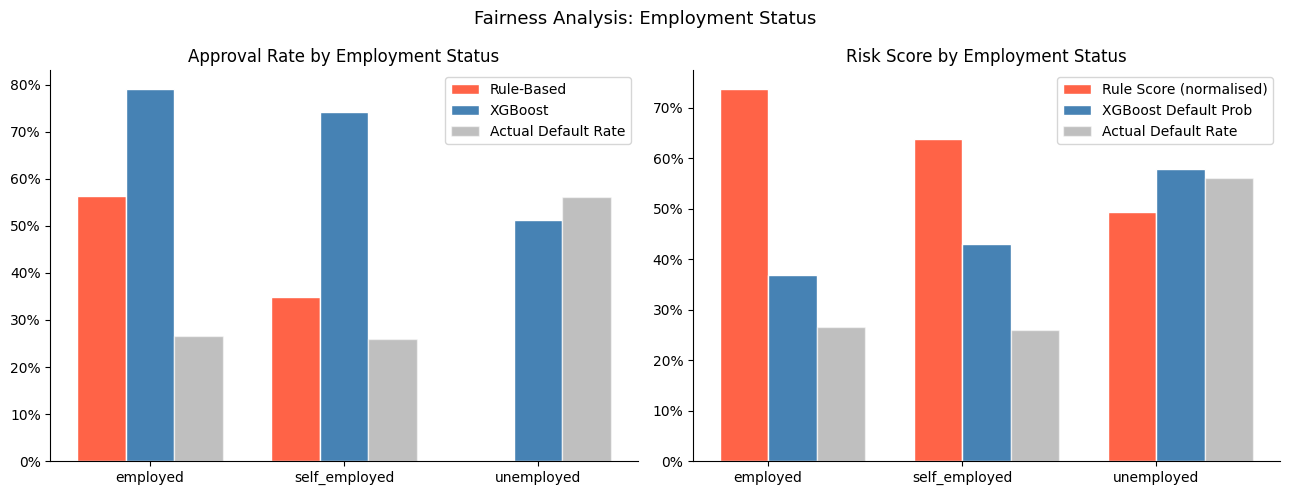

In [13]:
groups = fairness.index.tolist()
x = np.arange(len(groups))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - w, fairness['rule_approval_rate'], width=w, label='Rule-Based', color='tomato', edgecolor='white')
axes[0].bar(x,     fairness['ml_approval_rate'],   width=w, label='XGBoost',    color='steelblue', edgecolor='white')
axes[0].bar(x + w, fairness['actual_default_rate'], width=w, label='Actual Default Rate', color='gray', alpha=0.5, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups)
axes[0].set_title('Approval Rate by Employment Status')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

rule_score_by_emp = known.loc[X_test.index].groupby('employment_status')['rule_based_score'].mean()
ml_score_by_emp   = test_df.groupby('employment_status')['ml_prob'].mean()

axes[1].bar(x - w/2, rule_score_by_emp / 100, width=w, label='Rule Score (normalised)', color='tomato', edgecolor='white')
axes[1].bar(x + w/2, ml_score_by_emp,          width=w, label='XGBoost Default Prob',   color='steelblue', edgecolor='white')
axes[1].bar(x + w*1.5, fairness['actual_default_rate'], width=w, label='Actual Default Rate', color='gray', alpha=0.5, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups)
axes[1].set_title('Risk Score by Employment Status')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend()

plt.suptitle('Fairness Analysis: Employment Status', fontsize=13)
plt.tight_layout()
plt.savefig('plot_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Deploy-Tomorrow Numbers

In [17]:
n_test = len(y_test)
true_defaults = y_test.sum()
true_good     = n_test - true_defaults

ml_cm   = ml_metrics['cm']
rule_cm = rule_metrics['cm']

print('=== IF WE DEPLOYED TOMORROW ===')
print(f'\nTest set: {n_test} applicants — {true_defaults} actual defaults, {true_good} good applicants')

print(f'\nDefaults CAUGHT:')
print(f'  Rule-based : {rule_cm[1,1]} / {true_defaults} ({rule_cm[1,1]/true_defaults:.1%})')
print(f'  XGBoost    : {ml_cm[1,1]}   / {true_defaults} ({ml_cm[1,1]/true_defaults:.1%})')

print(f'\nGood applicants WRONGLY DENIED:')
print(f'  Rule-based : {rule_cm[0,1]} / {true_good} ({rule_cm[0,1]/true_good:.1%})')
print(f'  XGBoost    : {ml_cm[0,1]}   / {true_good} ({ml_cm[0,1]/true_good:.1%})')

print(f'\nNet change with XGBoost vs Rule-Based:')
print(f'  +{ml_cm[1,1] - rule_cm[1,1]} more defaults caught')
print(f'  {ml_cm[0,1] - rule_cm[0,1]:+d} change in wrongful denials')

=== IF WE DEPLOYED TOMORROW ===

Test set: 368 applicants — 109 actual defaults, 259 good applicants

Defaults CAUGHT:
  Rule-based : 36 / 109 (33.0%)
  XGBoost    : 57   / 109 (52.3%)

Good applicants WRONGLY DENIED:
  Rule-based : 22 / 259 (8.5%)
  XGBoost    : 37   / 259 (14.3%)

Net change with XGBoost vs Rule-Based:
  +21 more defaults caught
  +15 change in wrongful denials
